**Exercice 1**

In [ ]:
def is_palindrome(s):
    return s == s[::-1]

# Test avec "abbcbba"
print(is_palindrome("abbcbba"))  # Cela devrait retourner True


True


**Exercice 2**

In [ ]:
from collections import defaultdict

def find_anagrams(words):
    anagrams = defaultdict(list)
    for word in words:
        anagrams[''.join(sorted(word))].append(word)
    return dict(anagrams)

# Test avec l'exemple donné
words = ["chien", "niche", "écoute", "coute", "chien", "chien", "coute"]
print(find_anagrams(words))


{'cehin': ['chien', 'niche', 'chien', 'chien'], 'ceotué': ['écoute'], 'ceotu': ['coute', 'coute']}




```
# This is formatted as code
```

**Exercice 3**

In [ ]:
from collections import Counter
import re

def count_words(sentence):
    # Extract words in lowercase to ignore case differences
    words = re.findall(r'\b\w+\b', sentence.lower())
    # Use Counter to count occurrences of each word
    word_count = Counter(words)
    return dict(word_count)

# Test with "Bonjour le monde. Bonjour à tous dans le monde."
sentence = "Bonjour le monde. Bonjour à tous dans le monde."
print(count_words(sentence))


{'bonjour': 2, 'le': 2, 'monde': 2, 'à': 1, 'tous': 1, 'dans': 1}


**Exercie 4**

In [ ]:
def sum_nested_list(lst):
    total = 0
    for element in lst:
        if isinstance(element, list):  # Vérifie si l'élément est une liste
            total += sum_nested_list(element)  # Appel récursif pour les listes imbriquées
        else:
            total += element  # Ajoute l'élément s'il s'agit d'un nombre
    return total

# Test avec [1, 2, [3, 4], [5, 6]]
nested_list = [1, 2, [3, 4], [5, 6]]
print(sum_nested_list(nested_list))  # Résultat attendu: 21


21


**Partie 1**

In [ ]:
import yfinance as yf
import pandas as pd

# Liste des tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Télécharger les données pour plusieurs tickers
actions = yf.download(tickers, start='2021-10-30', end='2024-10-30', group_by='ticker')

# Créer une liste pour stocker les DataFrames
dataframes = []

# Parcourir chaque ticker pour créer un DataFrame avec la colonne Ticker
for ticker in tickers:
  df = actions[ticker].copy()  # Copie du DataFrame pour chaque ticker
  df['Ticker'] = ticker         # Ajouter la colonne Ticker
  dataframes.append(df)       # Ajouter le DataFrame à la liste

# Concaténer tous les DataFrames
final_df = pd.concat(dataframes, axis=0).reset_index()

# Afficher le DataFrame final
print(final_df[['Date', 'Ticker', 'Open', 'Close', 'Volume']])


[*********************100%***********************]  5 of 5 completed

Price                      Date Ticker        Open       Close     Volume
0     2021-11-01 00:00:00+00:00   AAPL  148.990005  148.960007   74588300
1     2021-11-02 00:00:00+00:00   AAPL  148.660004  150.020004   69122000
2     2021-11-03 00:00:00+00:00   AAPL  150.389999  151.490005   54511500
3     2021-11-04 00:00:00+00:00   AAPL  151.580002  150.960007   60394600
4     2021-11-05 00:00:00+00:00   AAPL  151.889999  151.279999   65463900
...                         ...    ...         ...         ...        ...
3760  2024-10-23 00:00:00+00:00   TSLA  217.130005  213.649994   80938900
3761  2024-10-24 00:00:00+00:00   TSLA  244.679993  260.480011  204491900
3762  2024-10-25 00:00:00+00:00   TSLA  256.010010  269.190002  161611900
3763  2024-10-28 00:00:00+00:00   TSLA  270.000000  262.510010  107653600
3764  2024-10-29 00:00:00+00:00   TSLA  264.510010  259.519989   80333700

[3765 rows x 5 columns]


**Partie 2**

In [ ]:
import yfinance as yf
import pandas as pd
import holidays

# Liste des tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Télécharger les données pour plusieurs tickers
actions = yf.download(tickers, start='2021-10-30', end='2024-10-30', group_by='ticker')

# Créer une liste pour stocker les DataFrames
dataframes = []

# Parcourir chaque ticker pour créer un DataFrame avec la colonne Ticker
for ticker in tickers:
    df = actions[ticker].copy()
    df['Ticker'] = ticker
    dataframes.append(df)

# Concaténer tous les DataFrames
final_df = pd.concat(dataframes, axis=0).reset_index()
final_df.rename(columns={'index': 'Date'}, inplace=True)

# Convertir la colonne Date de final_df en datetime sans timezone
final_df['Date'] = final_df['Date'].dt.tz_localize(None)

# Générer la liste des jours fériés aux États-Unis pour 2021-2024
us_holidays = holidays.US(years=[2021, 2022, 2023, 2024])
holiday_dates = pd.DataFrame({'Date': pd.to_datetime(list(us_holidays.keys()))})
holiday_dates['Holiday'] = True

# Joindre les jours fériés avec les données par une jointure gauche
final_df = final_df.merge(holiday_dates, on='Date', how='left')
final_df['Holiday'] = final_df['Holiday'].fillna(False)  # Remplir les valeurs NaN par False

# Filtrer pour conserver uniquement les jours ouvrés (Holiday == False)
working_days_df = final_df[final_df['Holiday'] == False].copy()

# Normalisation des prix (base commune pour comparer les actions)
working_days_df['Normalized_Close'] = working_days_df.groupby('Ticker')['Close'].transform(lambda x: x / x.iloc[0])

# Afficher le DataFrame final avec les prix normalisés et la colonne Holiday
print(working_days_df[['Date', 'Ticker', 'Open', 'Close', 'Volume', 'Holiday', 'Normalized_Close']])


[*********************100%***********************]  5 of 5 completed

           Date Ticker        Open       Close     Volume  Holiday  \
0    2021-11-01   AAPL  148.990005  148.960007   74588300    False   
1    2021-11-02   AAPL  148.660004  150.020004   69122000    False   
2    2021-11-03   AAPL  150.389999  151.490005   54511500    False   
3    2021-11-04   AAPL  151.580002  150.960007   60394600    False   
4    2021-11-05   AAPL  151.889999  151.279999   65463900    False   
...         ...    ...         ...         ...        ...      ...   
3760 2024-10-23   TSLA  217.130005  213.649994   80938900    False   
3761 2024-10-24   TSLA  244.679993  260.480011  204491900    False   
3762 2024-10-25   TSLA  256.010010  269.190002  161611900    False   
3763 2024-10-28   TSLA  270.000000  262.510010  107653600    False   
3764 2024-10-29   TSLA  264.510010  259.519989   80333700    False   

      Normalized_Close  
0             1.000000  
1             1.007116  
2             1.016984  
3             1.013426  
4             1.015575  
...      


<ipython-input-9-d8a07b4c8d15>:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['Holiday'] = final_df['Holiday'].fillna(False)  # Remplir les valeurs NaN par False


**Partie 3**

In [ ]:
import numpy as np
import yfinance as yf
import pandas as pd
import holidays

# Liste des tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Télécharger les données pour plusieurs tickers
actions = yf.download(tickers, start='2021-10-30', end='2024-10-30', group_by='ticker')

# Créer une liste pour stocker les DataFrames
dataframes = []

# Parcourir chaque ticker pour créer un DataFrame avec la colonne Ticker
for ticker in tickers:
    df = actions[ticker].copy()
    df['Ticker'] = ticker
    dataframes.append(df)

# Concaténer tous les DataFrames
final_df = pd.concat(dataframes, axis=0).reset_index()
final_df.rename(columns={'index': 'Date'}, inplace=True)

# Convertir la colonne Date de final_df en datetime sans timezone
final_df['Date'] = final_df['Date'].dt.tz_localize(None)

# Générer la liste des jours fériés aux États-Unis pour 2021-2024
us_holidays = holidays.US(years=[2021, 2022, 2023, 2024])
holiday_dates = pd.DataFrame({'Date': pd.to_datetime(list(us_holidays.keys()))})
holiday_dates['Holiday'] = True

# Joindre les jours fériés avec les données par une jointure gauche
final_df = final_df.merge(holiday_dates, on='Date', how='left')
final_df['Holiday'] = final_df['Holiday'].fillna(False)  # Remplir les valeurs NaN par False

# Filtrer pour conserver uniquement les jours ouvrés (Holiday == False)
working_days_df = final_df[final_df['Holiday'] == False].copy()

# Normalisation des prix (base commune pour comparer les actions)
working_days_df['Normalized_Close'] = working_days_df.groupby('Ticker')['Close'].transform(lambda x: x / x.iloc[0])

# Partie 3 : Calcul des métriques de performance
# 1. Rendements quotidiens
working_days_df['Daily_Return'] = working_days_df.groupby('Ticker')['Close'].pct_change()

# 2. Rendements quotidiens logarithmiques
# Calcul des rendements quotidiens logarithmiques
working_days_df['Log_Return'] = working_days_df.groupby('Ticker')['Close'].pct_change().apply(lambda x: np.log(1 + x))

# 3. Rendements cumulés
working_days_df['Cumulative_Return'] = (1 + working_days_df['Daily_Return']).groupby(working_days_df['Ticker']).cumprod()
working_days_df['Cumulative_Log_Return'] = working_days_df.groupby('Ticker')['Log_Return'].cumsum()

# 4. Volatilité annualisée avec une fenêtre glissante de 30 jours
working_days_df['Annualized_Volatility'] = (
    working_days_df.groupby('Ticker')['Daily_Return']
    .rolling(window=30)
    .std() * np.sqrt(252)
).reset_index(level=0, drop=True)

# 5. Ratio de Sharpe
# Hypothèse : taux sans risque de 2 % (0.02)
risk_free_rate = 0.02 / 252  # Taux sans risque quotidien (2 % annualisé)

# Calcul du rendement moyen quotidien par action
mean_daily_return = working_days_df.groupby('Ticker')['Daily_Return'].transform('mean')

# Ratio de Sharpe = (rendement moyen quotidien - taux sans risque) / volatilité quotidienne
working_days_df['Sharpe_Ratio'] = (mean_daily_return - risk_free_rate) / working_days_df.groupby('Ticker')['Daily_Return'].transform('std')

# Afficher les résultats finaux
print(working_days_df[['Date', 'Ticker', 'Close', 'Daily_Return', 'Log_Return', 'Cumulative_Return', 'Cumulative_Log_Return', 'Annualized_Volatility', 'Sharpe_Ratio']])


[*********************100%***********************]  5 of 5 completed

           Date Ticker       Close  Daily_Return  Log_Return  \
0    2021-11-01   AAPL  148.960007           NaN         NaN   
1    2021-11-02   AAPL  150.020004      0.007116    0.007091   
2    2021-11-03   AAPL  151.490005      0.009799    0.009751   
3    2021-11-04   AAPL  150.960007     -0.003499   -0.003505   
4    2021-11-05   AAPL  151.279999      0.002120    0.002117   
...         ...    ...         ...           ...         ...   
3760 2024-10-23   TSLA  213.649994     -0.019819   -0.020018   
3761 2024-10-24   TSLA  260.480011      0.219190    0.198187   
3762 2024-10-25   TSLA  269.190002      0.033438    0.032891   
3763 2024-10-28   TSLA  262.510010     -0.024815   -0.025128   
3764 2024-10-29   TSLA  259.519989     -0.011390   -0.011455   

      Cumulative_Return  Cumulative_Log_Return  Annualized_Volatility  \
0                   NaN                    NaN                    NaN   
1              1.007116               0.007091                    NaN   
2           


<ipython-input-15-887ad8baccc1>:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['Holiday'] = final_df['Holiday'].fillna(False)  # Remplir les valeurs NaN par False


**Partie 4**

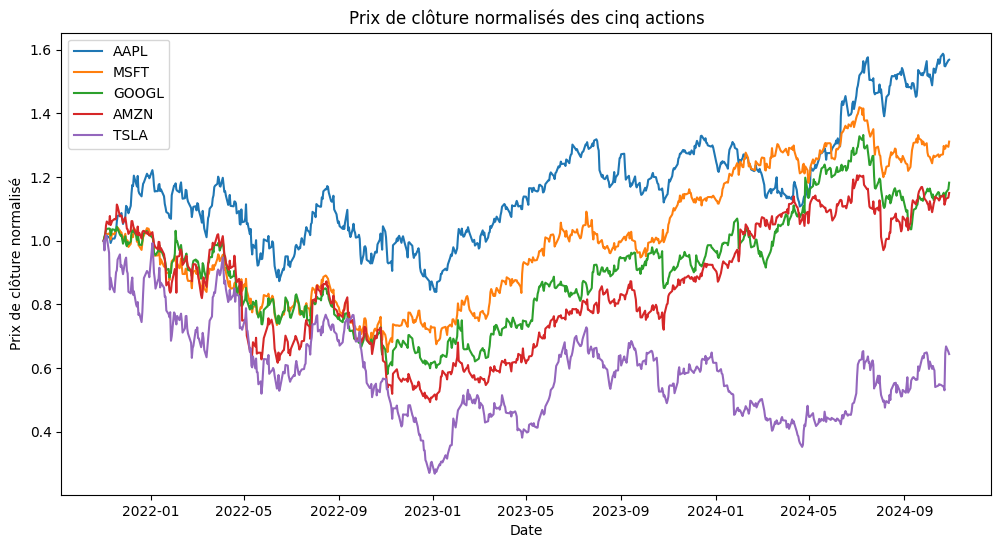

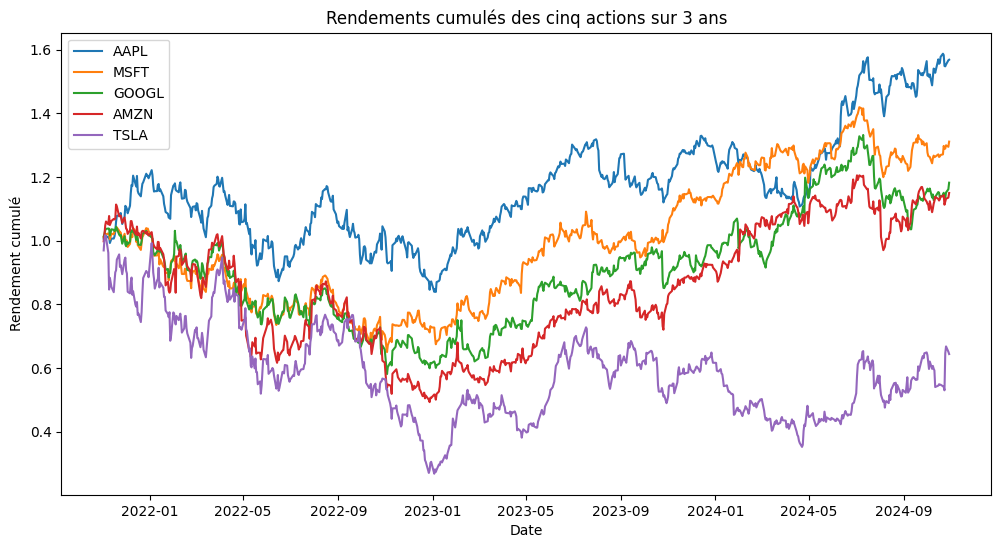

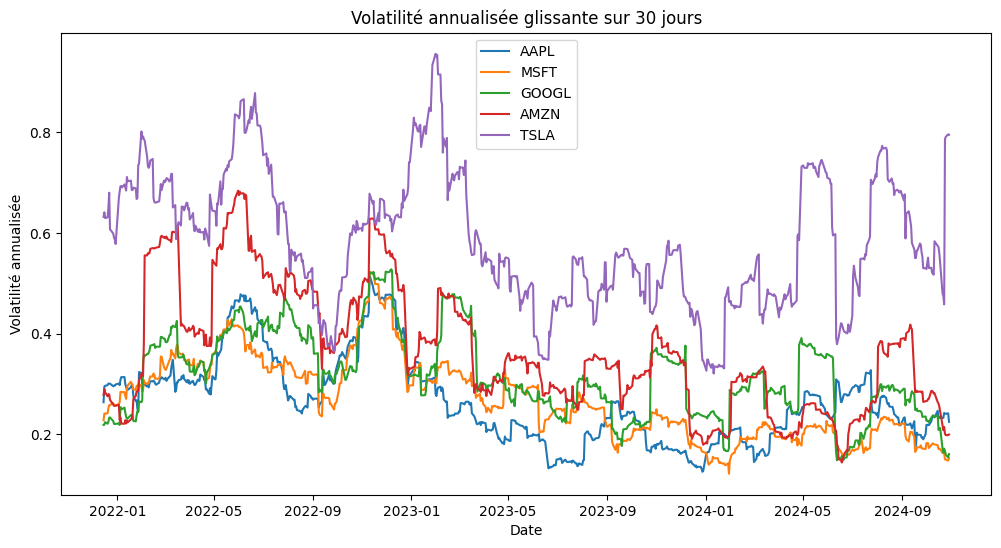

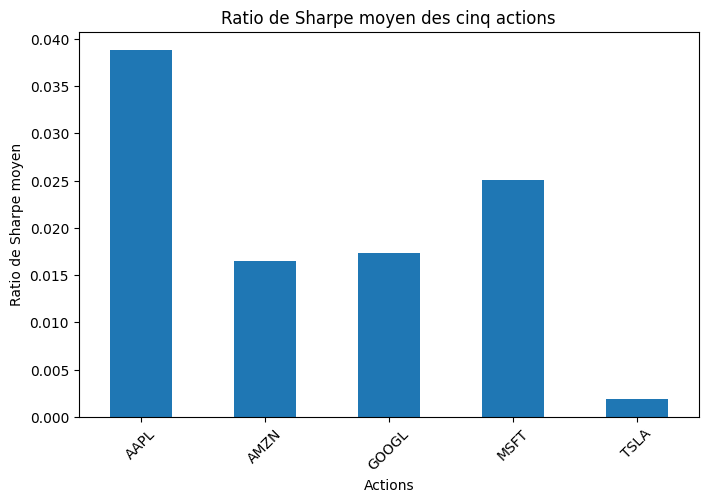

In [ ]:
import matplotlib.pyplot as plt

# 1. Graphique en ligne des prix de clôture normalisés
plt.figure(figsize=(12, 6))
for ticker in tickers:
    subset = working_days_df[working_days_df['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Normalized_Close'], label=ticker)
plt.title("Prix de clôture normalisés des cinq actions")
plt.xlabel("Date")
plt.ylabel("Prix de clôture normalisé")
plt.legend()
plt.show()

# 2. Graphique en ligne des rendements cumulés
plt.figure(figsize=(12, 6))
for ticker in tickers:
    subset = working_days_df[working_days_df['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Cumulative_Return'], label=ticker)
plt.title("Rendements cumulés des cinq actions sur 3 ans")
plt.xlabel("Date")
plt.ylabel("Rendement cumulé")
plt.legend()
plt.show()

# 3. Graphique en ligne de la volatilité annualisée glissante sur 30 jours
plt.figure(figsize=(12, 6))
for ticker in tickers:
    subset = working_days_df[working_days_df['Ticker'] == ticker]
    plt.plot(subset['Date'], subset['Annualized_Volatility'], label=ticker)
plt.title("Volatilité annualisée glissante sur 30 jours")
plt.xlabel("Date")
plt.ylabel("Volatilité annualisée")
plt.legend()
plt.show()

# 4. Graphique en barres du ratio de Sharpe
mean_sharpe_ratios = working_days_df.groupby('Ticker')['Sharpe_Ratio'].mean()
plt.figure(figsize=(8, 5))
mean_sharpe_ratios.plot(kind='bar')
plt.title("Ratio de Sharpe moyen des cinq actions")
plt.xlabel("Actions")
plt.ylabel("Ratio de Sharpe moyen")
plt.xticks(rotation=45)
plt.show()


**Partie 5**

In [22]:
def calculate_individual_sharpe_ratios(df, risk_free_rate=0.02):
    try:
        # Calcul des rendements moyens et de la matrice de covariance
        mean_returns, cov_matrix = calculate_returns_covariance(df)

        # Calcul de la volatilité annualisée pour chaque actif
        annualized_volatility = np.sqrt(np.diag(cov_matrix)) * np.sqrt(252)

        # Calcul du ratio de Sharpe pour chaque action
        sharpe_ratios = (mean_returns - risk_free_rate / 252) / annualized_volatility

        logging.info("Calcul des ratios de Sharpe individuels réussi.")
        logging.info(f"Ratios de Sharpe individuels: {sharpe_ratios}")

        # Afficher les ratios de Sharpe pour chaque action pour diagnostic
        print("Ratios de Sharpe individuels pour chaque action :")
        for ticker, ratio in sharpe_ratios.items():
            print(f"{ticker}: {ratio:.4f}")

        return sharpe_ratios
    except Exception as e:
        logging.error(f"Erreur lors du calcul des ratios de Sharpe individuels: {e}")
        raise

def optimize_portfolio_simplified(df, risk_free_rate=0.02):
    try:
        # Calcul des ratios de Sharpe individuels
        sharpe_ratios = calculate_individual_sharpe_ratios(df, risk_free_rate)

        # Identifier l'action avec le meilleur ratio de Sharpe
        best_asset_index = np.argmax(sharpe_ratios)
        best_asset = sharpe_ratios.index[best_asset_index]

        # Initialiser les pondérations : allouer 100% au meilleur actif, 0% aux autres
        optimal_weights = np.zeros(len(sharpe_ratios))
        optimal_weights[best_asset_index] = 1.0

        logging.info("Optimisation simplifiée de portefeuille réussie.")
        logging.info(f"Pondération optimale: {optimal_weights}")

        return best_asset, optimal_weights
    except Exception as e:
        logging.error(f"Erreur lors de l'optimisation simplifiée du portefeuille: {e}")
        raise

# Exécuter l'optimisation simplifiée pour obtenir le meilleur actif
best_asset, optimal_weights = optimize_portfolio_simplified(working_days_df)

# Afficher le résultat
print("\nMeilleur actif du portefeuille basé sur le ratio de Sharpe:")
print(f"{best_asset} avec une pondération de 100%")

Ratios de Sharpe individuels pour chaque action :
AAPL: 0.0024
AMZN: 0.0010
GOOGL: 0.0011
MSFT: 0.0016
TSLA: 0.0001

Meilleur actif du portefeuille basé sur le ratio de Sharpe:
AAPL avec une pondération de 100%
